In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv('/Users/sofia/Desktop/data science project/train.csv')
test_df = pd.read_csv('/Users/sofia/Desktop/data science project/train.csv')
oil_df = pd.read_csv('/Users/sofia/Desktop/data science project/oil.csv')
train_df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [4]:
# transform 'date' to time
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])
train_df['date'].dtypes

dtype('<M8[ns]')

In [5]:
# chek if there is any messing values in train_df
print(train_df.isnull().sum())
print('----------------check----------------')
print('There are missing values' if train_df.isnull().values.any() else 'There no missing values')

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64
----------------check----------------
There no missing values


           date  zeros_count
1683 2017-08-15          261
1682 2017-08-14          269
1681 2017-08-13          245
1680 2017-08-12          249
1679 2017-08-11          249
...         ...          ...
4    2013-01-05          905
3    2013-01-04          923
2    2013-01-03          931
1    2013-01-02          918
0    2013-01-01         1765

[1684 rows x 2 columns]
===================================Visualization of zeros_count by date===================================


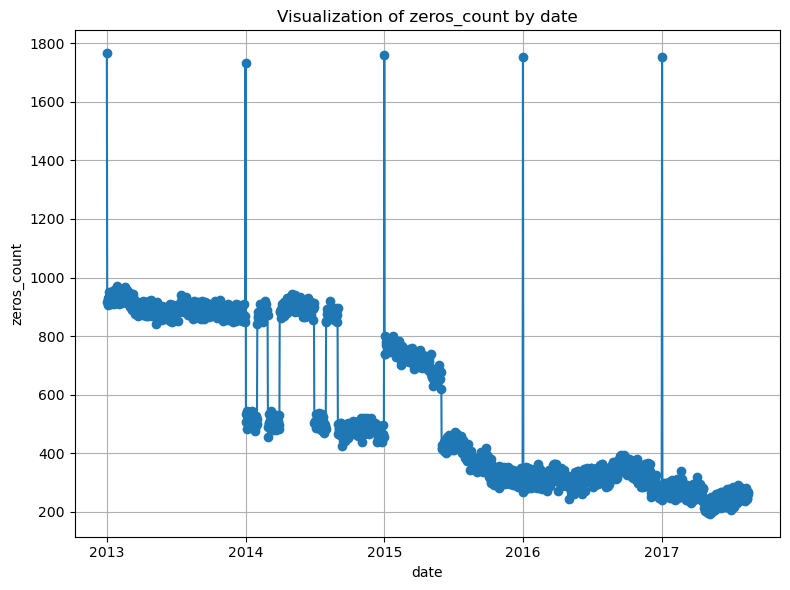

In [6]:
# Check and analyze the 'sales == 0' values by date
sales_null_perday = train_df[train_df['sales'] == 0].groupby('date').size().reset_index(name = 'zeros_count')
sales_null_perday = sales_null_perday.sort_values(by = 'date', ascending = False )
print(sales_null_perday)
print('===================================Visualization of zeros_count by date===================================')
# time serie plot Visualization of null sales by date
plt.figure(figsize = (8, 6))
plt.plot(sales_null_perday['date'], sales_null_perday['zeros_count'], marker = 'o', linestyle = '-')
plt.title('Visualization of zeros_count by date')
plt.xlabel('date')
plt.ylabel('zeros_count')
plt.grid(True)
plt.tight_layout()

**(New Year's Day). On this day, almost all stores in Ecuador (the source of the data) are closed** \
*The Result*: Zero sales for all stores and all products, which explains why the count reached its peak.

**Notice how the overall number of zeros was high in 2013, then dropped suddenly in mid-2014, and decreased even further in 2015**\
*The Interpretation*: This means that the stores became more efficient over time, or that new products began to be sold and were no longer recording zeros as before.

**There are periods in the plot where the number of zeros drops very sharply and then returns**\
*The Interpretation*: These are often periods of "major sales" or national events where demand increased to the point that zeros almost disappeared from the records.

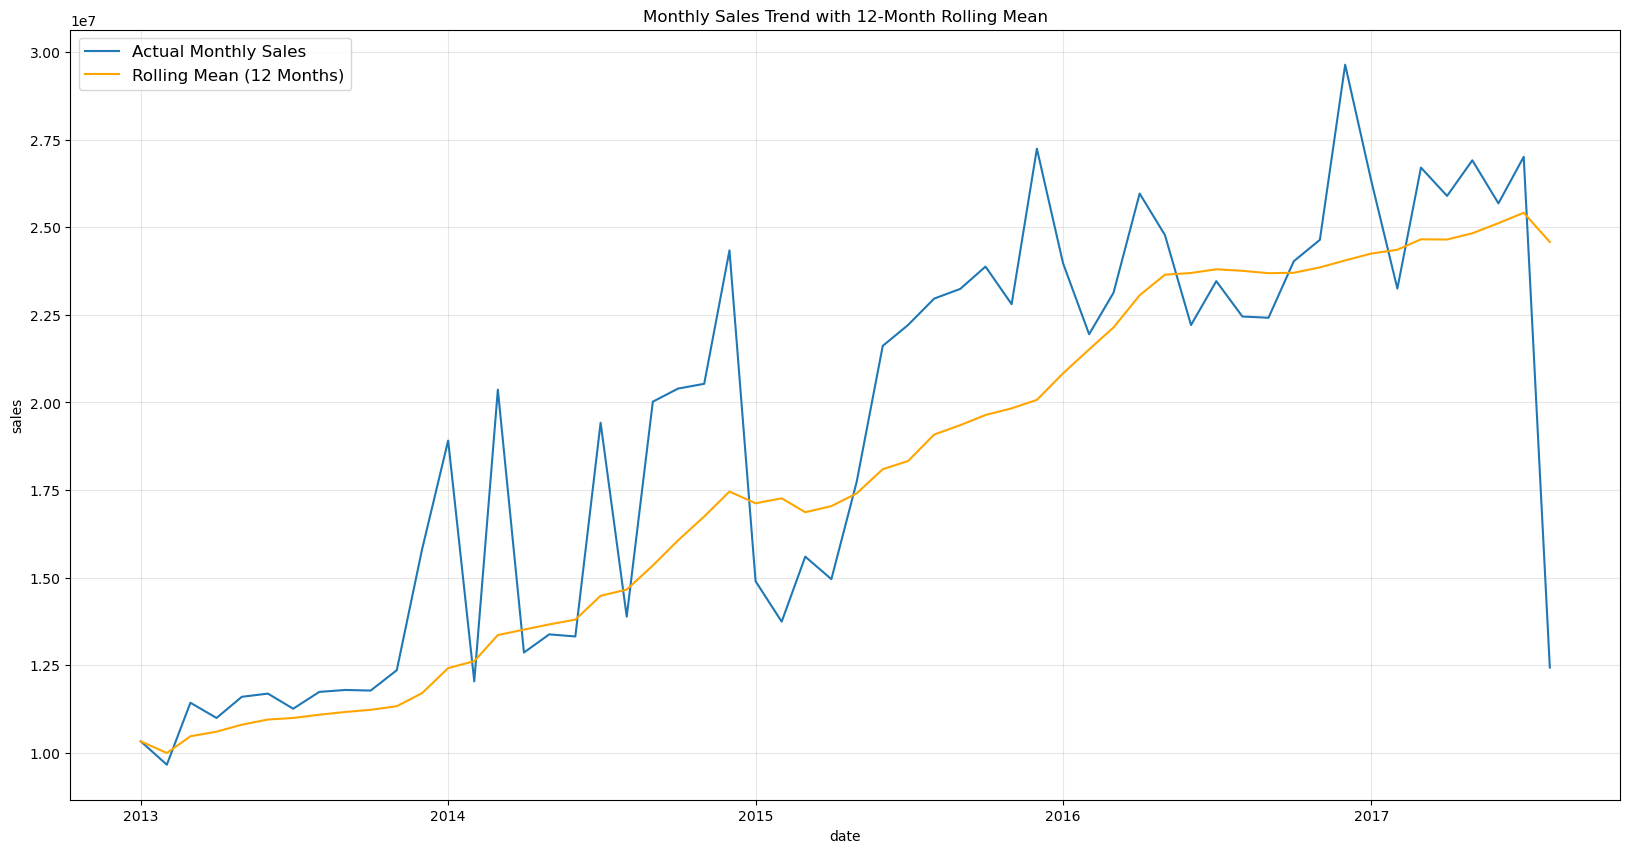

In [7]:
# Inspecting time series and rolling mean:
timeseries = train_df.groupby(train_df['date'].dt.to_period('M'))['sales'].sum().reset_index()
timeseries['date'] = timeseries['date'].dt.to_timestamp()
timeseries = timeseries.set_index('date')

timeseries['rolling_mean'] = timeseries['sales'].rolling(window=12, min_periods=1).mean()

plt.figure(figsize=(20, 10))

sns.lineplot(data=timeseries, x=timeseries.index, y='sales', label="Actual Monthly Sales")

sns.lineplot(data=timeseries, x=timeseries.index, y='rolling_mean', label="Rolling Mean (12 Months)", color='orange')

plt.title('Monthly Sales Trend with 12-Month Rolling Mean')
plt.legend(fontsize='large')
plt.grid(True, alpha=0.3) 
plt.show()

In [8]:
# Feature engineering
train_df['event'] = 'NormalDay'
train_df.loc[(train_df['date'].dt.day == 1) & (train_df['date'].dt.month == 1), 'event'] = 'NewYearDay'

test_df['event'] = 'NormalDay'
test_df.loc[(test_df['date'].dt.day == 1) & (test_df['date'].dt.month == 1), 'event'] = 'NewYearDay'

train_df

,id,date,store_nbr,family,sales,onpromotion,event
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,NewYearDay
1,1,2013-01-01,1,BABY CARE,0.000,0,NewYearDay
2,2,2013-01-01,1,BEAUTY,0.000,0,NewYearDay
3,3,2013-01-01,1,BEVERAGES,0.000,0,NewYearDay
4,4,2013-01-01,1,BOOKS,0.000,0,NewYearDay
...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,NormalDay
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,NormalDay
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,NormalDay
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,NormalDay


In [9]:
train_df['onpromotion'].unique()

array([  0,   3,   5,   1,  56,  20,  19,   2,   4,  18,  17,  12,   6,
         7,  10,   9,  50,   8,  16,  42,  51,  13,  15,  47,  21,  40,
        37,  54,  24,  58,  22,  59,  11,  45,  25,  55,  26,  43,  35,
        14,  28,  46,  36,  32,  53,  57,  27,  39,  41,  30,  29,  49,
        23,  48,  44,  38,  31,  52,  33,  34,  61,  60, 116,  86,  73,
       113, 102,  68, 104,  93,  70,  92, 121,  72, 178, 174, 161, 118,
       105, 172, 163, 167, 142, 154, 133, 180, 181, 173, 165, 168, 186,
       140, 149, 145, 169, 188,  62,  84, 111,  65, 107,  63, 101,  87,
       125,  94, 114, 171, 153, 170, 166, 141, 155, 179, 192, 131, 147,
       151, 189,  79,  74, 110,  64,  67,  99, 123, 157, 117, 150, 182,
       162, 160, 194, 135, 190,  69, 108,  89, 126, 156, 103, 146, 132,
       177, 164, 176, 112,  75, 109,  91, 128, 175, 187, 148, 137, 184,
       196, 144, 158, 119, 106,  66, 100,  90, 120, 115,  98, 159, 152,
       185, 139, 143,  80, 124,  71, 134, 193,  78,  88, 122, 13

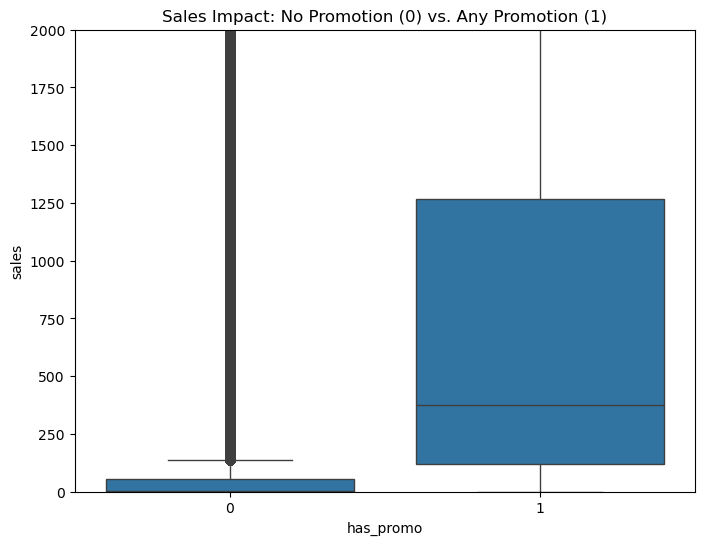

In [10]:
train_df['has_promo'] = train_df['onpromotion'].apply(lambda x: 1 if x > 0 else 0)
test_df['has_promo'] = test_df['onpromotion'].apply(lambda x: 1 if x > 0 else 0)

plt.figure(figsize=(8, 6))
sns.boxplot(x='has_promo', y='sales', data=train_df)
plt.title('Sales Impact: No Promotion (0) vs. Any Promotion (1)')
plt.ylim(0, 2000) 
plt.show()

C:\Users\sofia\AppData\Local\Temp\ipykernel_21480\4155664836.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_analysis = train_df.groupby('promo_bins')['sales'].mean().reset_index()
C:\Users\sofia\AppData\Local\Temp\ipykernel_21480\4155664836.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bin_analysis['promo_bins'].astype(str), y=bin_analysis['sales'], palette='viridis')


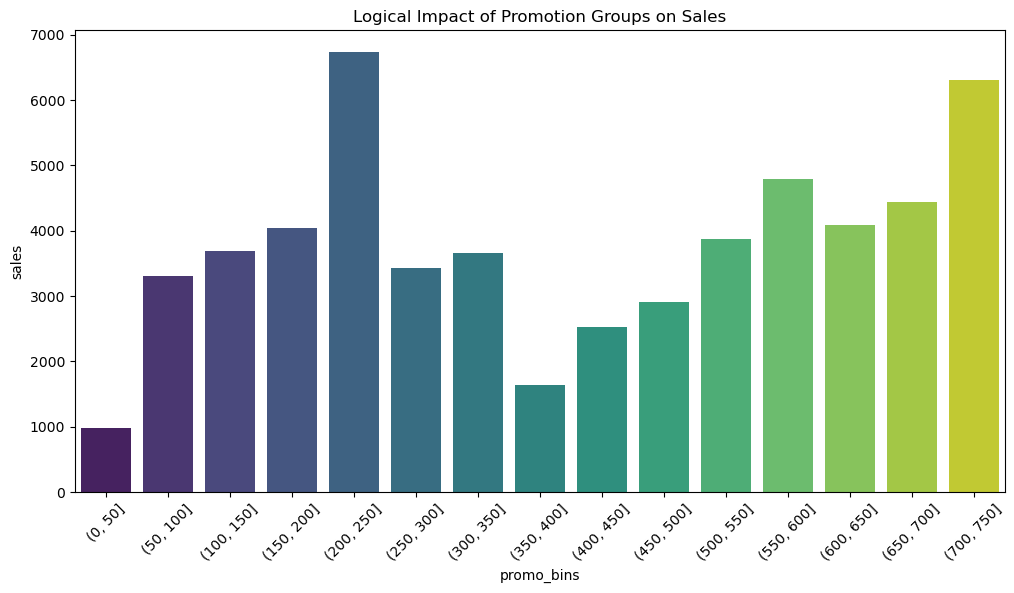

In [11]:
train_df['promo_bins'] = pd.cut(train_df['onpromotion'], bins=range(0, 800, 50))
bin_analysis = train_df.groupby('promo_bins')['sales'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x=bin_analysis['promo_bins'].astype(str), y=bin_analysis['sales'], palette='viridis')
plt.xticks(rotation=45)
plt.title('Logical Impact of Promotion Groups on Sales')
plt.show()

In [12]:
train_df.drop(columns = ['promo_bins'], inplace = True)
train_df['promotion'] = 'No_Promotion'
train_df.loc[(train_df['onpromotion'] != 0), 'promotion'] = 'Has_Promotion'

test_df['promotion'] = 'No_Promotion'
test_df.loc[(test_df['onpromotion'] != 0), 'promotion'] = 'Has_Promotion'

train_df

,id,date,store_nbr,family,sales,onpromotion,event,has_promo,promotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,NewYearDay,0,No_Promotion
1,1,2013-01-01,1,BABY CARE,0.000,0,NewYearDay,0,No_Promotion
2,2,2013-01-01,1,BEAUTY,0.000,0,NewYearDay,0,No_Promotion
3,3,2013-01-01,1,BEVERAGES,0.000,0,NewYearDay,0,No_Promotion
4,4,2013-01-01,1,BOOKS,0.000,0,NewYearDay,0,No_Promotion
...,...,...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,NormalDay,0,No_Promotion
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,NormalDay,1,Has_Promotion
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,NormalDay,1,Has_Promotion
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,NormalDay,1,Has_Promotion


### Analyzed and processed oil price data

In [13]:
oil_df

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
...,...,...
1213,2017-08-25,47.65
1214,2017-08-28,46.40
1215,2017-08-29,46.46
1216,2017-08-30,45.96


In [14]:
oil_df.isnull().sum()

date           0
dcoilwtico    43
dtype: int64

In [15]:
oil_df['date'] = pd.to_datetime(oil_df['date'])
oil_df.dtypes

date          datetime64[ns]
dcoilwtico           float64
dtype: object

In [16]:
oil_df['day'] = oil_df['date'].dt.day_name()
oil_df

,date,dcoilwtico,day
0,2013-01-01,NaN,Tuesday
1,2013-01-02,93.14,Wednesday
2,2013-01-03,92.97,Thursday
3,2013-01-04,93.12,Friday
4,2013-01-07,93.20,Monday
...,...,...,...
1213,2017-08-25,47.65,Friday
1214,2017-08-28,46.40,Monday
1215,2017-08-29,46.46,Tuesday
1216,2017-08-30,45.96,Wednesday


In [17]:
oil_df['day'].unique()

array(['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Monday'],
      dtype=object)

In [18]:
days_nan = oil_df.groupby('day')['dcoilwtico'].apply(lambda x : x.isnull().sum())
days_nan

day
Friday        9
Monday       23
Thursday      7
Tuesday       2
Wednesday     2
Name: dcoilwtico, dtype: int64

In [19]:
# check oil price in Wednesday 
Wednesday_oil_price = oil_df[oil_df['day'] == 'Wednesday']['dcoilwtico']
Wednesday_oil_price.unique()

array([ 93.14,  93.08,  94.28,  95.06,  97.98,  96.44,  97.03,  94.92,
        92.84,  90.47,  92.47,  93.21,  96.53,  95.02,  94.59,  86.65,
        91.07,  90.74,  96.24,  93.95,  93.98,  93.13,  93.66,  95.98,
        98.24,  95.47, 101.92, 106.41, 106.39, 105.41, 105.1 , 104.41,
       106.89, 103.93, 110.17, 107.29, 107.65, 108.23, 102.68, 104.15,
       101.63, 102.34,  96.9 ,  96.81,  94.74,  93.91,  93.34,  92.05,
        96.97,  97.25,  97.59,    nan,  91.9 ,  93.78,  96.35,  97.34,
        97.4 , 100.38, 103.46, 102.93, 101.75,  98.29, 100.71, 100.61,
        99.6 , 103.55, 103.71, 101.47, 100.07, 101.06, 102.63, 104.31,
       103.37, 103.27, 105.04, 106.64, 107.04, 105.18, 101.88, 103.81,
       104.29,  96.93,  97.57,  96.4 ,  95.82,  95.5 ,  91.71,  94.33,
        93.6 ,  87.29,  81.82,  80.52,  82.25,  78.71,  77.16,  74.55,
        73.7 ,  67.3 ,  60.99,  56.43,  55.7 ,  53.45,  48.69,  48.49,
        47.85,  44.08,  48.45,  48.8 ,  52.13,  50.25,  51.53,  48.06,
      

In [20]:
Nan_wednesday = (oil_df['day'] == 'Wednesday') & (oil_df['dcoilwtico'].isna())
oil_df.loc[Nan_wednesday, 'dcoilwtico'] = oil_df['dcoilwtico'].interpolate(method='linear').loc[Nan_wednesday]
print("wednesday messing values after update:")
print(oil_df[oil_df['day'] == 'Wednesday']['dcoilwtico'].isnull().sum())

wednesday messing values after update:
0


In [21]:
# check oil price in Tuesday 
Tuesday_oil_price = oil_df[oil_df['day'] == 'Tuesday']['dcoilwtico']
Tuesday_oil_price.unique()

array([   nan,  93.21,  93.26,  96.09,  97.62,  96.68,  97.48,  96.69,
        92.63,  90.88,  92.44,  95.99,  97.23,  94.18,  88.73,  89.21,
        93.22,  95.28,  93.96,  95.55,  94.65,  93.36,  95.5 ,  98.46,
        95.25,  99.65, 103.46, 105.88, 107.13, 103.14, 105.32, 106.78,
       104.9 , 109.11, 108.67, 107.48, 105.36, 103.22, 102.09, 103.54,
       101.15,  97.63,  98.29,  93.4 ,  93.12,  93.35,  93.41,  95.83,
        98.32,  96.99,  98.87,  98.17,  93.31,  92.15,  94.51,  97.49,
        97.24,  99.96, 102.54, 102.2 , 103.64, 100.29, 100.08,  99.66,
        99.69, 102.57, 103.7 , 101.69, 101.56,  99.81, 102.01, 102.8 ,
       104.78, 103.34, 105.02, 106.95, 106.64, 106.06, 104.06, 100.56,
       104.59, 104.91,  97.34,  97.36,  94.35,  95.78,  92.92,  92.73,
        94.91,  91.55,  91.17,  88.89,  81.72,  83.25,  81.36,  77.15,
        77.85,  74.55,  74.04,  66.99,  63.74,  55.97,  56.78,  54.14,
        47.98,  45.92,  46.79,  45.84,  53.04,  50.06,  53.56,  48.48,
      

In [22]:
Nan_Tuesday = (oil_df['day'] == 'Tuesday') & (oil_df['dcoilwtico'].isna())

next_val_1 = oil_df['dcoilwtico'].shift(-1)
next_val_2 = oil_df['dcoilwtico'].shift(-2)
calculated_mean = (next_val_1 + next_val_2) / 2
oil_df.loc[Nan_Tuesday, 'dcoilwtico'] = calculated_mean.loc[Nan_Tuesday]
print("Tuesday messing values after update:")
print(oil_df[oil_df['day'] == 'Tuesday']['dcoilwtico'].isnull().sum())

Tuesday messing values after update:
0


In [23]:
# now in Tuesday and Wednesday we have 0 messing values of oil price 

In [24]:
# Thursday oil price 
(oil_df[oil_df['day'] == 'Thursday']['dcoilwtico']).unique()

array([ 92.97,  93.81,  95.49,  95.35,  97.65,  95.84,  97.3 ,  92.79,
        92.03,  91.53,  93.03,  92.46,  97.24,  93.26,  93.44,  87.83,
        93.27,  93.7 ,  96.09,  94.85,  94.12,  93.57,  94.71,  96.66,
        94.89,  97.  ,    nan, 104.77, 107.94, 105.47, 107.93, 103.45,
       107.43, 104.93, 108.51, 108.5 , 108.72, 106.26, 103.1 , 103.29,
       103.08, 100.72,  96.65,  96.29,  94.25,  93.76,  97.14,  97.21,
        98.4 ,  99.18,  95.14,  91.36,  93.54,  97.23,  98.25,  97.84,
       100.27, 103.2 , 102.68, 101.82,  98.57,  99.68, 101.25, 100.29,
       103.37, 104.33, 102.2 ,  99.69, 100.52, 101.74, 104.03, 104.26,
       103.17, 107.2 , 107.08, 106.49, 104.76, 103.61, 103.84, 102.76,
        98.23,  97.34,  95.54,  93.97,  96.44,  94.51,  92.89,  93.07,
        93.59,  91.02,  85.76,  82.33,  82.81,  81.06,  77.87,  74.13,
        75.63,  66.73,  60.01,  54.18,  48.8 ,  46.37,  45.93,  44.12,
        50.48,  51.17,  51.12,  47.65,  50.76,  47.12,  44.02,  51.41,
      

In [25]:
thursday_nan_rows = oil_df[(oil_df['day'] == 'Thursday') & (oil_df.isnull().any(axis=1))]
print(thursday_nan_rows)

           date  dcoilwtico       day
132  2013-07-04         NaN  Thursday
237  2013-11-28         NaN  Thursday
497  2014-11-27         NaN  Thursday
517  2014-12-25         NaN  Thursday
522  2015-01-01         NaN  Thursday
757  2015-11-26         NaN  Thursday
1017 2016-11-24         NaN  Thursday


In [26]:
Nan_thursday = (oil_df['day'] == 'Thursday') & (oil_df['dcoilwtico'].isna())
oil_df.loc[Nan_thursday, 'dcoilwtico'] = oil_df['dcoilwtico'].interpolate(method='linear').loc[Nan_thursday]
print("thursday messing values after update:")
print(oil_df[oil_df['day'] == 'Thursday']['dcoilwtico'].isnull().sum())

thursday messing values after update:
0


In [27]:
# Friday oil price 
print('the some of messing values in Friday is:')
oil_df[oil_df['day'] == 'Friday']['dcoilwtico'].isnull().sum()


the some of messing values in Friday is:


9

In [28]:
Nan_Friday = (oil_df['day'] == 'Friday') & (oil_df['dcoilwtico'].isna())
prev_val1 = oil_df['dcoilwtico'].shift(1)  
prev_val2 = oil_df['dcoilwtico'].shift(2) 
calculated_mean = (prev_val1 + prev_val2) / 2
oil_df.loc[Nan_Friday, 'dcoilwtico'] = calculated_mean.loc[Nan_Friday]
print(f"Missing values for Friday: {oil_df[oil_df['day'] == 'Friday']['dcoilwtico'].isnull().sum()}")

Missing values for Friday: 0


In [29]:
# Monday oil price 
print('the some of messing values in Monday is:')
oil_df[oil_df['day'] == 'Monday']['dcoilwtico'].isnull().sum()

the some of messing values in Monday is:


23

In [30]:
# To handle missing oil price values on Monday, we can use the following mathematical formula:
import math
def monday_oil_price(PTuesday, PFriday):
    r = math.log(PTuesday / PFriday)
    PMonday = PFriday * math.exp(r / 2)
    return PMonday

oil_df = oil_df.sort_values('date').reset_index(drop = True)
for i in range(len(oil_df)) :
    if oil_df.loc[i, 'day'] == 'Monday' and pd.isna(oil_df.loc[i, 'dcoilwtico']) :
        try :
            PFriday = oil_df.loc[i-1, 'dcoilwtico']
            PTuesday = oil_df.loc[i+1, 'dcoilwtico']

            monday_price = monday_oil_price(PTuesday, PFriday)
            oil_df.loc[i, 'dcoilwtico'] = monday_price
        except (KeyError, IndexError, ValueError):
            continue

print(f"Missing values for Monday: {oil_df[oil_df['day'] == 'Monday']['dcoilwtico'].isnull().sum()}")

Missing values for Monday: 0


In [31]:
#check again if there any messing values in oil price
new_oil_price = oil_df.groupby('day')['dcoilwtico'].apply(lambda x : x.isnull().sum())
new_oil_price
# there is no messing values in oil price

day
Friday       0
Monday       0
Thursday     0
Tuesday      0
Wednesday    0
Name: dcoilwtico, dtype: int64

In [32]:
# now we need to mergre oil_df with train_df
oil_df

,date,dcoilwtico,day
0,2013-01-01,93.055,Tuesday
1,2013-01-02,93.140,Wednesday
2,2013-01-03,92.970,Thursday
3,2013-01-04,93.120,Friday
4,2013-01-07,93.200,Monday
...,...,...,...
1213,2017-08-25,47.650,Friday
1214,2017-08-28,46.400,Monday
1215,2017-08-29,46.460,Tuesday
1216,2017-08-30,45.960,Wednesday


In [35]:
train_df = train_df.merge(oil_df[['date', 'dcoilwtico', 'day']], on='date', how='left')
test_df = test_df.merge(oil_df[['date', 'dcoilwtico', 'day']], on='date', how='left')

train_df

,id,date,store_nbr,family,sales,onpromotion,event,has_promo,promotion,dcoilwtico_x,day_x,dcoilwtico_y,day_y
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,Tuesday
1,1,2013-01-01,1,BABY CARE,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,Tuesday
2,2,2013-01-01,1,BEAUTY,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,Tuesday
3,3,2013-01-01,1,BEVERAGES,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,Tuesday
4,4,2013-01-01,1,BOOKS,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.570,Tuesday
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,NormalDay,1,Has_Promotion,47.570,Tuesday,47.570,Tuesday
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,NormalDay,1,Has_Promotion,47.570,Tuesday,47.570,Tuesday
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,NormalDay,1,Has_Promotion,47.570,Tuesday,47.570,Tuesday


In [39]:
train_df.drop(columns = ['day_y', 'dcoilwtico_y'], inplace = True)
train_df = train_df.rename(columns={'dcoilwtico_x': 'oil_price'})
train_df = train_df.rename(columns={'day_x': 'day'})

test_df.drop(columns = ['day_y', 'dcoilwtico_y'], inplace = True)
test_df = test_df.rename(columns={'dcoilwtico_x': 'oil_price'})
test_df = test_df.rename(columns={'day_x': 'day'})

train_df

,id,date,store_nbr,family,sales,onpromotion,event,has_promo,promotion,oil_price,day
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday
1,1,2013-01-01,1,BABY CARE,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday
2,2,2013-01-01,1,BEAUTY,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday
3,3,2013-01-01,1,BEVERAGES,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday
4,4,2013-01-01,1,BOOKS,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,NormalDay,0,No_Promotion,47.570,Tuesday
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,NormalDay,1,Has_Promotion,47.570,Tuesday
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,NormalDay,1,Has_Promotion,47.570,Tuesday
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,NormalDay,1,Has_Promotion,47.570,Tuesday


In [40]:
train_df['day'] = train_df['date'].dt.day_name()
test_df['day'] = test_df['date'].dt.day_name()

In [41]:
# check again if there is any messing values 
train_df.groupby('day')['oil_price'].apply(lambda x : x.isnull().sum())

day
Friday            0
Monday            0
Saturday     429462
Sunday       427680
Thursday          0
Tuesday           0
Wednesday         0
Name: oil_price, dtype: int64

In [42]:
train_df = train_df.sort_values('date')
train_df['oil_price'] = train_df['oil_price'].ffill()

test_df = test_df.sort_values('date')
test_df['oil_price'] = test_df['oil_price'].ffill()

print('check after update, some of messing values is :')
train_df.groupby('day')['oil_price'].apply(lambda x : x.isnull().sum())

check after update, some of messing values is :


day
Friday       0
Monday       0
Saturday     0
Sunday       0
Thursday     0
Tuesday      0
Wednesday    0
Name: oil_price, dtype: int64

C:\Users\sofia\AppData\Local\Temp\ipykernel_21480\1746727667.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = train_df.groupby('price_bin')['sales'].mean().reset_index()


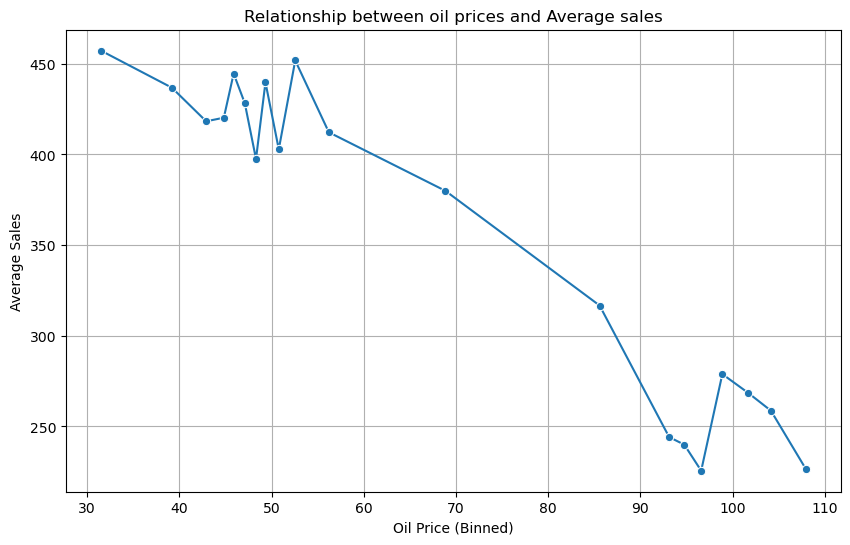

In [43]:
train_df['price_bin'] = pd.qcut(train_df['oil_price'], q=20)
binned_data = train_df.groupby('price_bin')['sales'].mean().reset_index()
binned_data['price_center'] = binned_data['price_bin'].apply(lambda x: x.mid)
plt.figure(figsize=(10, 6))
sns.lineplot(data=binned_data, x='price_center', y='sales', marker='o')
plt.title('Relationship between oil prices and Average sales')
plt.xlabel('Oil Price (Binned)')
plt.ylabel('Average Sales')
plt.grid(True)
plt.show()

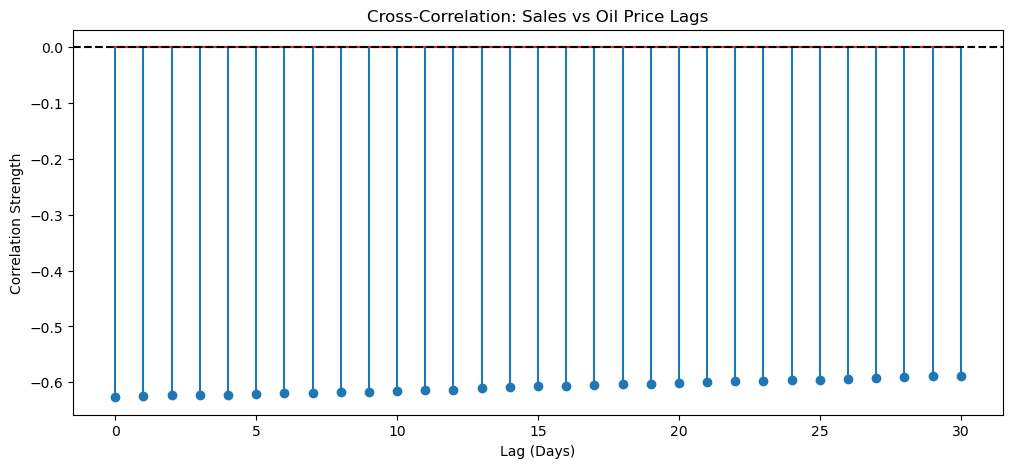

In [44]:
import statsmodels.api as sm
df_daily = train_df.groupby('date')[['sales', 'oil_price']].mean().resample('D').ffill()
ccf_values = sm.tsa.stattools.ccf(df_daily['sales'], df_daily['oil_price'], adjusted=False)[:31]
plt.figure(figsize=(12, 5))
plt.stem(range(len(ccf_values)), ccf_values)
plt.axhline(y=0, color='k', linestyle='--')
plt.title('Cross-Correlation: Sales vs Oil Price Lags')
plt.xlabel('Lag (Days)')
plt.ylabel('Correlation Strength')
plt.show()

**The Cross-Correlation (CCF) analysis reveals a significant and sustained negative correlation (approximately -0.62) between oil prices and sales. This inverse relationship is not merely instantaneous but persists steadily across a 30-day window, suggesting that consumer behavior is influenced by the cumulative pressure of high fuel costs rather than daily fluctuations. The stability of the correlation from Lag 0 to Lag 30 indicates that the sales volume is highly sensitive to the broader price trend. Consequently, incorporating a 30-day moving average and a 1-day lag is essential for the model to capture both the immediate price shocks and the long-term erosion of consumer purchasing power.**

In [45]:
oil_mapping = train_df[['date', 'oil_price']].drop_duplicates().sort_values('date')
oil_mapping['oil_lag1'] = oil_mapping['oil_price'].shift(1)
train_df = train_df.merge(oil_mapping[['date', 'oil_lag1']], on='date', how='left')

oil_mapping_test = test_df[['date', 'oil_price']].drop_duplicates().sort_values('date')
oil_mapping_test['oil_lag1'] = oil_mapping_test['oil_price'].shift(1)
test_df = test_df.merge(oil_mapping_test[['date', 'oil_lag1']], on='date', how='left')

In [46]:
train_df

,id,date,store_nbr,family,sales,onpromotion,event,has_promo,promotion,oil_price,day,price_bin,oil_lag1
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,"(92.43, 93.8]",NaN
1,1194,2013-01-01,42,CELEBRATION,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,"(92.43, 93.8]",NaN
2,1193,2013-01-01,42,BREAD/BAKERY,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,"(92.43, 93.8]",NaN
3,1192,2013-01-01,42,BOOKS,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,"(92.43, 93.8]",NaN
4,1191,2013-01-01,42,BEVERAGES,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,"(92.43, 93.8]",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,2999693,2017-08-15,25,PET SUPPLIES,3.000,0,NormalDay,0,No_Promotion,47.570,Tuesday,"(46.378, 47.79]",47.59
3000884,2999692,2017-08-15,25,PERSONAL CARE,93.000,8,NormalDay,1,Has_Promotion,47.570,Tuesday,"(46.378, 47.79]",47.59
3000885,2999691,2017-08-15,25,MEATS,180.107,0,NormalDay,0,No_Promotion,47.570,Tuesday,"(46.378, 47.79]",47.59
3000886,2999702,2017-08-15,26,BEAUTY,0.000,0,NormalDay,0,No_Promotion,47.570,Tuesday,"(46.378, 47.79]",47.59


In [47]:
train_df['oil_lag1'] = train_df.groupby('date')['oil_lag1'].transform(lambda x: x.bfill()).bfill()
test_df['oil_lag1'] = test_df.groupby('date')['oil_lag1'].transform(lambda x: x.bfill()).bfill()

In [48]:
train_df.drop(columns = ['price_bin'], inplace = True)
train_df

,id,date,store_nbr,family,sales,onpromotion,event,has_promo,promotion,oil_price,day,oil_lag1
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055
1,1194,2013-01-01,42,CELEBRATION,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055
2,1193,2013-01-01,42,BREAD/BAKERY,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055
3,1192,2013-01-01,42,BOOKS,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055
4,1191,2013-01-01,42,BEVERAGES,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055
...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,2999693,2017-08-15,25,PET SUPPLIES,3.000,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590
3000884,2999692,2017-08-15,25,PERSONAL CARE,93.000,8,NormalDay,1,Has_Promotion,47.570,Tuesday,47.590
3000885,2999691,2017-08-15,25,MEATS,180.107,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590
3000886,2999702,2017-08-15,26,BEAUTY,0.000,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590


**In this section, we examine the relationship between Oil Prices and the Average Promotion Intensity. By binning the oil prices into 20 quantiles and calculating the mean of onpromotion, we can identify if the retail strategy compensates for high oil prices (which we previously found to negatively correlate with sales) by increasing promotional activities.**

C:\Users\sofia\AppData\Local\Temp\ipykernel_21480\22311291.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = train_df.groupby('promo_bin')['onpromotion'].mean().reset_index()


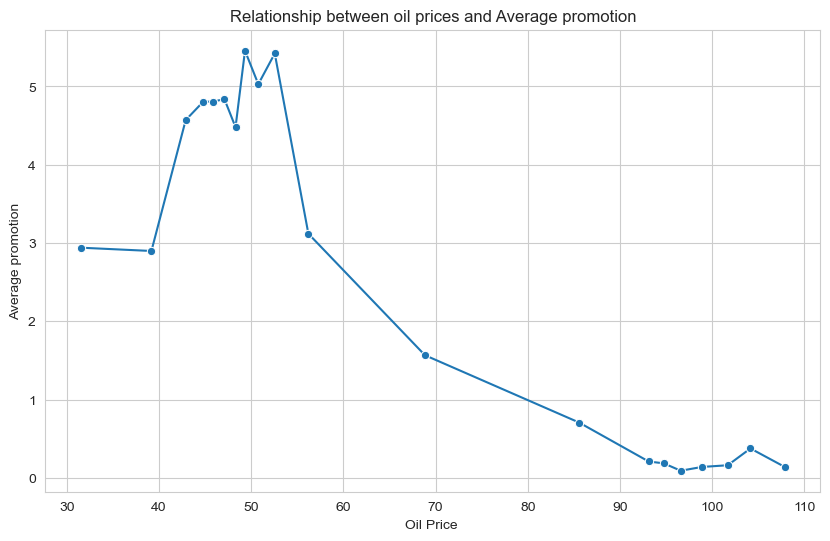

In [64]:
train_df['promo_bin'] = pd.qcut(train_df['oil_price'], q=20)
binned_data = train_df.groupby('promo_bin')['onpromotion'].mean().reset_index()
binned_data['promo_center'] = binned_data['promo_bin'].apply(lambda x: x.mid)
plt.figure(figsize=(10, 6))
sns.lineplot(data=binned_data, x='promo_center', y='onpromotion', marker='o')
plt.title('Relationship between oil prices and Average promotion')
plt.xlabel('Oil Price ')
plt.ylabel('Average promotion')
plt.grid(True)
plt.show()

**The analysis reveals a "Negative Synergy" between oil prices and sales. As oil prices exceed the $60 threshold, we observe a dramatic collapse in promotional activities (dropping from an average of 5 to near 0). This suggests that high fuel costs not only reduce consumer purchasing power but also strain the retailer's operational budget, forcing a total withdrawal of promotions. This dual impact explains the persistent -0.62 correlation observed in the CCF plots; sales drop and stay low because the "promotional engine" of the store shuts down whenever oil prices are high.**

C:\Users\sofia\AppData\Local\Temp\ipykernel_21480\760272886.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = train_df.groupby('promo_bin')['onpromotion'].mean().reset_index()


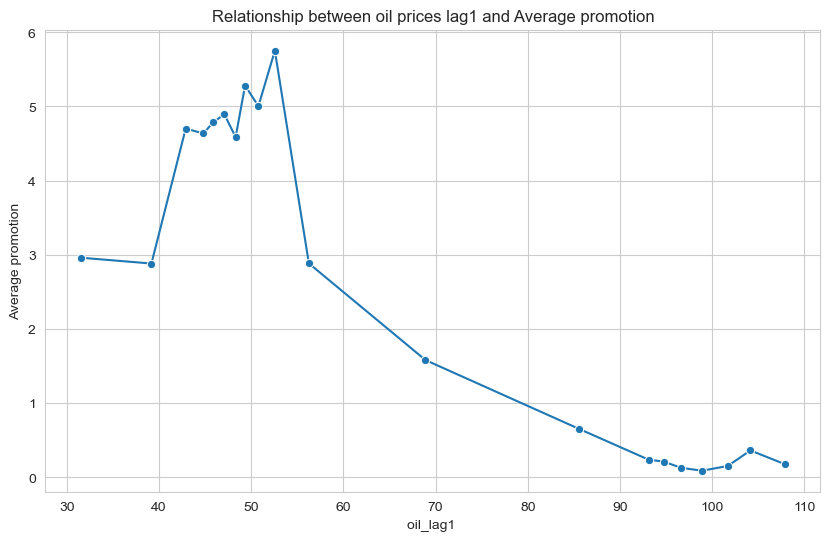

In [63]:
train_df['promo_bin'] = pd.qcut(train_df['oil_lag1'], q=20)
binned_data = train_df.groupby('promo_bin')['onpromotion'].mean().reset_index()
binned_data['promo_center'] = binned_data['promo_bin'].apply(lambda x: x.mid)
plt.figure(figsize=(10, 6))
sns.lineplot(data=binned_data, x='promo_center', y='onpromotion', marker='o')
plt.title('Relationship between oil prices lag1 and Average promotion')
plt.xlabel('oil_lag1 ')
plt.ylabel('Average promotion')
plt.grid(True)
plt.show()

In [51]:
# Based on the previous visualization, we can create another strong feature
def classify_promo_oil(price) :
    if price < 50 :
        return 'high_promotion'
    elif price > 70 :
        return 'low_promotion'
    else :
        return 'mid_promotion'
train_df['oil_impact_promotion'] = train_df['oil_price'].apply(classify_promo_oil)
test_df['oil_impact_promotion'] = test_df['oil_price'].apply(classify_promo_oil)

In [52]:
mapping = {
    'high_promotion': 'low_oil_pressure',  
    'low_promotion': 'high_oil_pressure',   
    'mid_promotion': 'mid_oil_pressure'
}
train_df['oil_budget_status'] = train_df['oil_impact_promotion'].map(mapping)
test_df['oil_budget_status'] = test_df['oil_impact_promotion'].map(mapping)

In [53]:
train_df

,id,date,store_nbr,family,sales,onpromotion,event,has_promo,promotion,oil_price,day,oil_lag1,promo_bin,oil_impact_promotion,oil_budget_status
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,"(92.44, 93.8]",low_promotion,high_oil_pressure
1,1194,2013-01-01,42,CELEBRATION,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,"(92.44, 93.8]",low_promotion,high_oil_pressure
2,1193,2013-01-01,42,BREAD/BAKERY,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,"(92.44, 93.8]",low_promotion,high_oil_pressure
3,1192,2013-01-01,42,BOOKS,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,"(92.44, 93.8]",low_promotion,high_oil_pressure
4,1191,2013-01-01,42,BEVERAGES,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,"(92.44, 93.8]",low_promotion,high_oil_pressure
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,2999693,2017-08-15,25,PET SUPPLIES,3.000,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590,"(46.378, 47.79]",high_promotion,low_oil_pressure
3000884,2999692,2017-08-15,25,PERSONAL CARE,93.000,8,NormalDay,1,Has_Promotion,47.570,Tuesday,47.590,"(46.378, 47.79]",high_promotion,low_oil_pressure
3000885,2999691,2017-08-15,25,MEATS,180.107,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590,"(46.378, 47.79]",high_promotion,low_oil_pressure
3000886,2999702,2017-08-15,26,BEAUTY,0.000,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590,"(46.378, 47.79]",high_promotion,low_oil_pressure


In [54]:
train_df.drop(columns = ['promo_bin', 'oil_impact_promotion'], inplace = True)
train_df

,id,date,store_nbr,family,sales,onpromotion,event,has_promo,promotion,oil_price,day,oil_lag1,oil_budget_status
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure
1,1194,2013-01-01,42,CELEBRATION,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure
2,1193,2013-01-01,42,BREAD/BAKERY,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure
3,1192,2013-01-01,42,BOOKS,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure
4,1191,2013-01-01,42,BEVERAGES,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,2999693,2017-08-15,25,PET SUPPLIES,3.000,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590,low_oil_pressure
3000884,2999692,2017-08-15,25,PERSONAL CARE,93.000,8,NormalDay,1,Has_Promotion,47.570,Tuesday,47.590,low_oil_pressure
3000885,2999691,2017-08-15,25,MEATS,180.107,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590,low_oil_pressure
3000886,2999702,2017-08-15,26,BEAUTY,0.000,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590,low_oil_pressure


<Axes: >

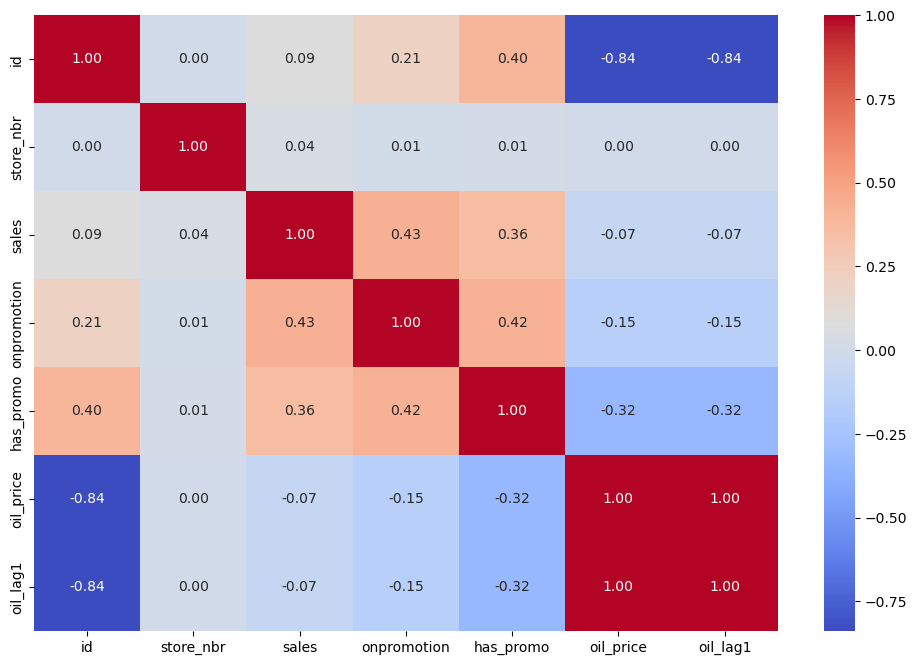

In [55]:
correlation_matrix = train_df.corr(numeric_only = True)
plt.figure(figsize = (12, 8))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')

**While the Pearson Correlation matrix provides a foundational view of the data, its low coefficient between oil prices and sales (-0.07) suggests that a simple linear model may overlook the true impact of fuel costs on retail performance. The perfect multicollinearity between oil_price and oil_lag1 (1.00) indicates redundant information, while the strong correlation between onpromotion and sales (0.43) confirms promotional activity as a key driver. However, because our visual EDA revealed distinct "regime shifts" and threshold-based behavior specifically where promotional intensity collapses as oil prices rise—we must move beyond linear metrics. By employing Mutual Information (MI), we can capture these complex, non-linear dependencies and quantify the "information gain" provided by our engineered features, ensuring the model prioritizes variables that represent the actual economic logic of the marketplace.**

In [56]:
# Mutual Information 
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

df_sample = train_df.sample(200000, random_state=42)
X = df_sample[['onpromotion', 'oil_price', 'oil_lag1', 'has_promo', 'event', 'oil_budget_status']].copy()
y = df_sample['sales']

le = LabelEncoder()
categorical_cols = ['event', 'oil_budget_status']

for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

discrete_mask = [False, False, False, True, True, True]
mi_scores = mutual_info_regression(X, y, discrete_features=discrete_mask, random_state=42)

for name, score in zip(X.columns, mi_scores):
    print(f"Feature: {name}, MI Score: {score:.4f}")


Feature: onpromotion, MI Score: 0.2026
Feature: oil_price, MI Score: 0.0538
Feature: oil_lag1, MI Score: 0.0530
Feature: has_promo, MI Score: 0.1700
Feature: event, MI Score: 0.0033
Feature: oil_budget_status, MI Score: 0.0339


C:\Users\sofia\AppData\Local\Temp\ipykernel_21480\3265920257.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='MI Score', y='Feature', data=mi_results, palette=palette)


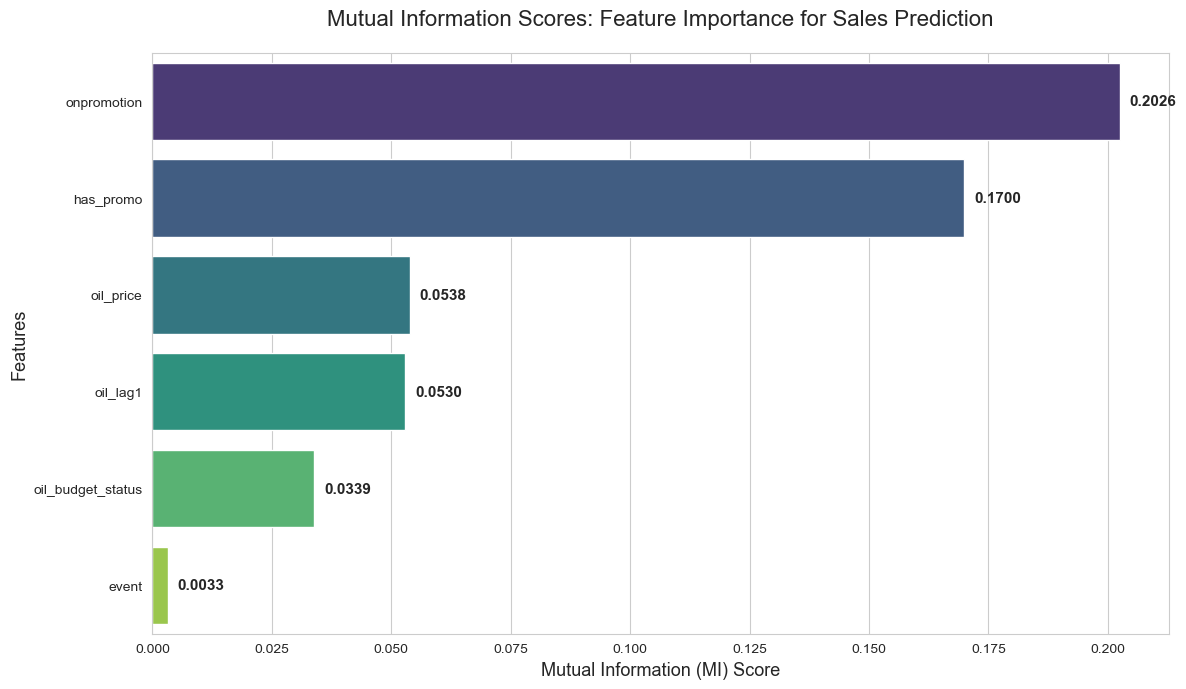

In [57]:
mi_results = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
mi_results = mi_results.sort_values(by='MI Score', ascending=False)
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
palette = sns.color_palette("viridis", len(mi_results))
ax = sns.barplot(x='MI Score', y='Feature', data=mi_results, palette=palette)

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.002, p.get_y() + p.get_height()/2, 
             f'{width:.4f}', 
             va='center', fontsize=11, fontweight='bold')

plt.title('Mutual Information Scores: Feature Importance for Sales Prediction', fontsize=16, pad=20)
plt.xlabel('Mutual Information (MI) Score', fontsize=13)
plt.ylabel('Features', fontsize=13)
plt.tight_layout()

plt.show()

In [58]:
train_df['promo_efficiency'] = train_df['onpromotion'] * (1 / (train_df['oil_price'] + 1))
test_df['promo_efficiency'] = test_df['onpromotion'] * (1 / (test_df['oil_price'] + 1))

In [59]:
df_sample = train_df.sample(300000, random_state=42)
X = df_sample[['onpromotion', 'oil_price', 'oil_lag1', 'has_promo', 'event', 'oil_budget_status', 'promo_efficiency']].copy()
y = df_sample['sales']

le = LabelEncoder()
categorical_cols = ['event', 'oil_budget_status']
for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

discrete_mask = [False, False, False, True, True, True, False]

mi_scores = mutual_info_regression(X, y, discrete_features=discrete_mask, random_state=42)

for name, score in zip(X.columns, mi_scores):
    print(f"Feature: {name}, MI Score: {score:.4f}")

Feature: onpromotion, MI Score: 0.2066
Feature: oil_price, MI Score: 0.0523
Feature: oil_lag1, MI Score: 0.0532
Feature: has_promo, MI Score: 0.1701
Feature: event, MI Score: 0.0032
Feature: oil_budget_status, MI Score: 0.0335
Feature: promo_efficiency, MI Score: 0.2081


C:\Users\sofia\AppData\Local\Temp\ipykernel_21480\2371847021.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='MI Score', y='Feature', data=mi_results, palette='mako')


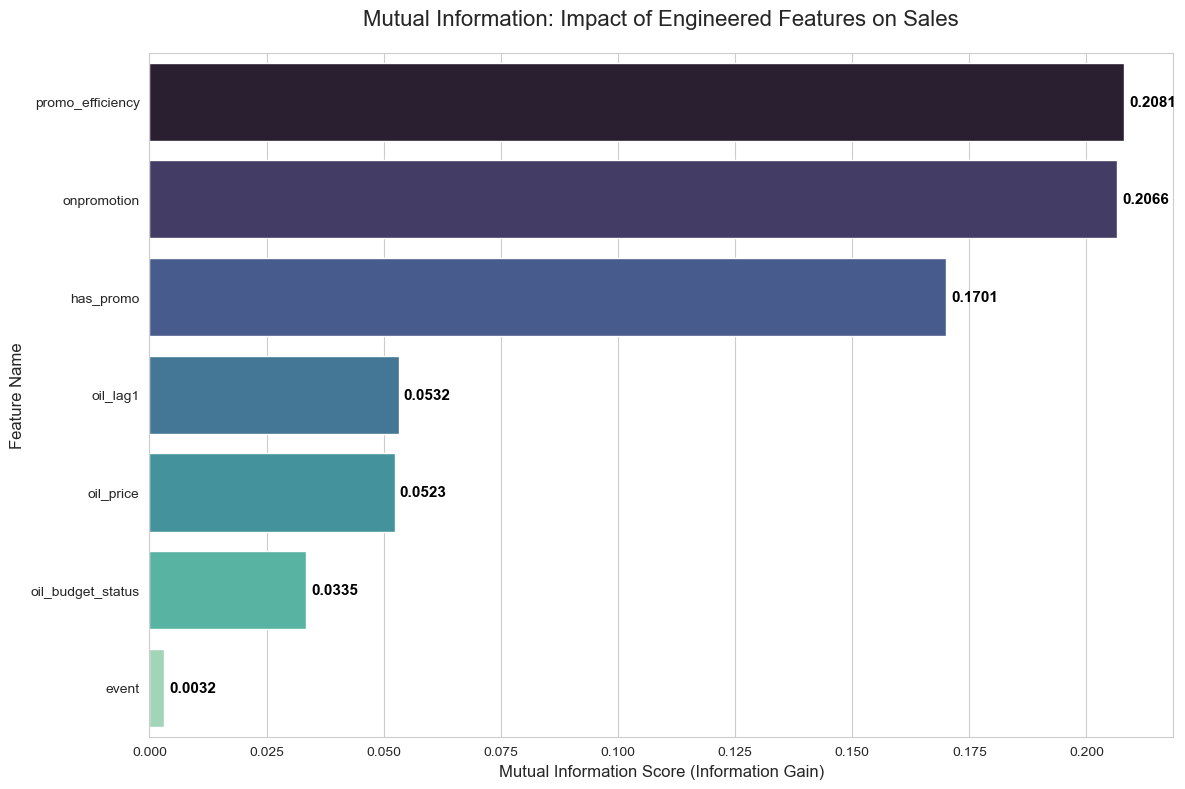

In [60]:
mi_results = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
mi_results = mi_results.sort_values(by='MI Score', ascending=False)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
ax = sns.barplot(x='MI Score', y='Feature', data=mi_results, palette='mako')
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.001, p.get_y() + p.get_height()/2, 
             f'{width:.4f}', 
             va='center', fontsize=11, fontweight='bold', color='black')

plt.title('Mutual Information: Impact of Engineered Features on Sales', fontsize=16, pad=20)
plt.xlabel('Mutual Information Score (Information Gain)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

plt.tight_layout()
plt.show()

In [62]:
train_df

,id,date,store_nbr,family,sales,onpromotion,event,has_promo,promotion,oil_price,day,oil_lag1,oil_budget_status,promo_efficiency
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.000000
1,1194,2013-01-01,42,CELEBRATION,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.000000
2,1193,2013-01-01,42,BREAD/BAKERY,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.000000
3,1192,2013-01-01,42,BOOKS,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.000000
4,1191,2013-01-01,42,BEVERAGES,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,2999693,2017-08-15,25,PET SUPPLIES,3.000,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590,low_oil_pressure,0.000000
3000884,2999692,2017-08-15,25,PERSONAL CARE,93.000,8,NormalDay,1,Has_Promotion,47.570,Tuesday,47.590,low_oil_pressure,0.164711
3000885,2999691,2017-08-15,25,MEATS,180.107,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590,low_oil_pressure,0.000000
3000886,2999702,2017-08-15,26,BEAUTY,0.000,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590,low_oil_pressure,0.000000


In [75]:
# Visualization of the average sales by product family and day

<Figure size 1400x1200 with 0 Axes>

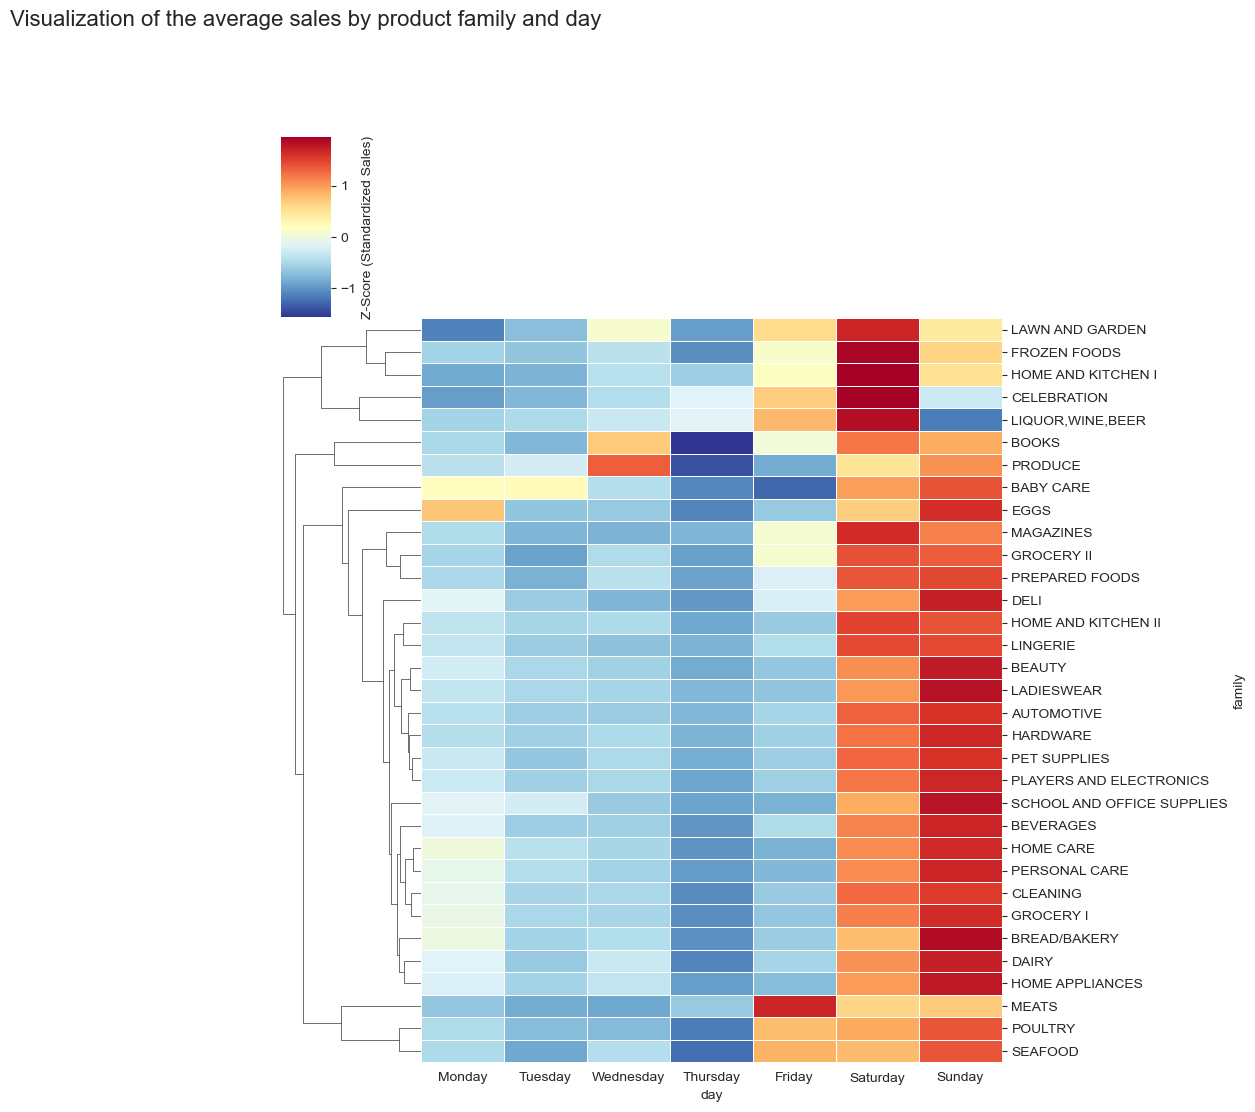

In [76]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
matrix = train_df.groupby(['family', 'day'])['sales'].mean().unstack()
matrix = matrix[days_order]
matrix_zscore = matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
plt.figure(figsize=(14, 12))
g = sns.clustermap(matrix_zscore, 
                   cmap='RdYlBu_r', 
                   col_cluster=False, 
                   annot=False, 
                   linewidths=.5,
                   cbar_kws={'label': 'Z-Score (Standardized Sales)'})
plt.title('Visualization of the average sales by product family and day', fontsize=16, pad=80)
plt.show()

In [79]:
from sklearn.cluster import AgglomerativeClustering 
from sklearn.preprocessing import StandardScaler
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
matrix = train_df.groupby(['family', 'day'])['sales'].mean().unstack()[days_order]
scaler = StandardScaler()
matrix_scaled = scaler.fit_transform(matrix.T).T

n_clusters = 4
clusters_model = AgglomerativeClustering(n_clusters = n_clusters)
cluster_labels = clusters_model.fit_predict(matrix_scaled)
weekend_effect = pd.DataFrame({
    'family' : matrix.index,
    'temporal_cluster' : cluster_labels
})
train_df = train_df.merge(weekend_effect, on = 'family', how = 'left')
for i in range(n_clusters) :
    print(f"\n----------------------- group {i} -------------------------")
    print(weekend_effect[weekend_effect['temporal_cluster'] == i]['family'].values)    


----------------------- group 0 -------------------------
['FROZEN FOODS' 'GROCERY II' 'HOME AND KITCHEN I' 'LAWN AND GARDEN'
 'MAGAZINES' 'MEATS' 'POULTRY' 'PREPARED FOODS' 'SEAFOOD']

----------------------- group 1 -------------------------
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BREAD/BAKERY' 'CLEANING'
 'DAIRY' 'DELI' 'EGGS' 'GROCERY I' 'HARDWARE' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LINGERIE' 'PERSONAL CARE'
 'PET SUPPLIES' 'PLAYERS AND ELECTRONICS' 'SCHOOL AND OFFICE SUPPLIES']

----------------------- group 2 -------------------------
['CELEBRATION' 'LIQUOR,WINE,BEER']

----------------------- group 3 -------------------------
['BOOKS' 'PRODUCE']


**In this project, we didn't just look at sales as boring numbers; we looked for the "rhythm" of how people shop. By using the colorful heatmap, we discovered that products have different "personalities." For example, "Meats" start selling fast on Fridays to prepare for the weekend, while "Produce" (fruits and vegetables) has a special peak in the middle of the week. Since we couldn't study every single product one by one, we used a smart tool called Clustering to group products into 4 families based on "when" people buy them.**

In [81]:
train_df.head()

,id,date,store_nbr,family,sales,onpromotion,event,has_promo,promotion,oil_price,day,oil_lag1,oil_budget_status,promo_efficiency,promo_bin,temporal_cluster_x,temporal_cluster_y
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.0,"(92.43, 93.8]",1,1
1,1194,2013-01-01,42,CELEBRATION,0.0,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.0,"(92.43, 93.8]",2,2
2,1193,2013-01-01,42,BREAD/BAKERY,0.0,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.0,"(92.43, 93.8]",1,1
3,1192,2013-01-01,42,BOOKS,0.0,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.0,"(92.43, 93.8]",3,3
4,1191,2013-01-01,42,BEVERAGES,0.0,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.0,"(92.43, 93.8]",1,1


In [82]:
train_df.drop(columns = ['promo_bin', 'temporal_cluster_x'], inplace = True)
train_df = train_df.rename(columns={'temporal_cluster_y': 'weekend_effect'})
train_df

,id,date,store_nbr,family,sales,onpromotion,event,has_promo,promotion,oil_price,day,oil_lag1,oil_budget_status,promo_efficiency,weekend_effect
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.000000,1
1,1194,2013-01-01,42,CELEBRATION,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.000000,2
2,1193,2013-01-01,42,BREAD/BAKERY,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.000000,1
3,1192,2013-01-01,42,BOOKS,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.000000,3
4,1191,2013-01-01,42,BEVERAGES,0.000,0,NewYearDay,0,No_Promotion,93.055,Tuesday,93.055,high_oil_pressure,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,2999693,2017-08-15,25,PET SUPPLIES,3.000,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590,low_oil_pressure,0.000000,1
3000884,2999692,2017-08-15,25,PERSONAL CARE,93.000,8,NormalDay,1,Has_Promotion,47.570,Tuesday,47.590,low_oil_pressure,0.164711,1
3000885,2999691,2017-08-15,25,MEATS,180.107,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590,low_oil_pressure,0.000000,0
3000886,2999702,2017-08-15,26,BEAUTY,0.000,0,NormalDay,0,No_Promotion,47.570,Tuesday,47.590,low_oil_pressure,0.000000,1


In [84]:
test_df = test_df.merge(weekend_effect, on='family', how='left')

In [86]:
test_df.rename(columns={'temporal_cluster': 'weekend_effect'}, inplace=True)


In [90]:
# check with mutual information again
df_sample = train_df.sample(300000, random_state=42)
X = df_sample[['onpromotion', 'oil_price', 'oil_lag1', 'has_promo', 'event', 'oil_budget_status', 'promo_efficiency', 'weekend_effect']].copy()
y = df_sample['sales']

le = LabelEncoder()
categorical_cols = ['event', 'oil_budget_status']
for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

discrete_mask = [False, False, False, True, True, True, False, True]

mi_scores = mutual_info_regression(X, y, discrete_features=discrete_mask, random_state=42)

for name, score in zip(X.columns, mi_scores):
    print(f"Feature: {name}, MI Score: {score:.4f}")

Feature: onpromotion, MI Score: 0.2066
Feature: oil_price, MI Score: 0.0523
Feature: oil_lag1, MI Score: 0.0532
Feature: has_promo, MI Score: 0.1701
Feature: event, MI Score: 0.0032
Feature: oil_budget_status, MI Score: 0.0335
Feature: promo_efficiency, MI Score: 0.2081
Feature: weekend_effect, MI Score: 0.1819


C:\Users\sofia\AppData\Local\Temp\ipykernel_21480\1173557001.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette=palette)


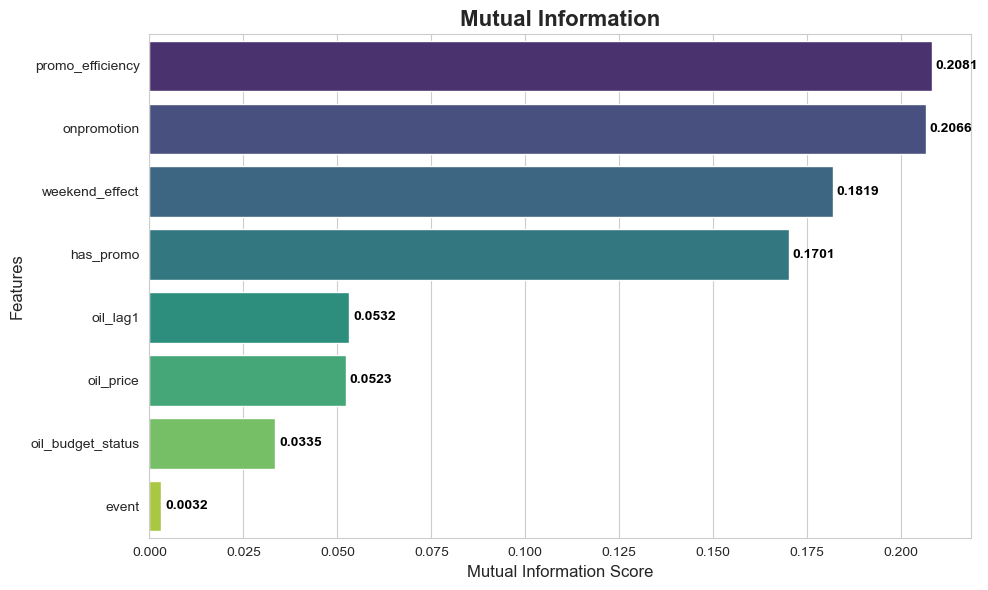

In [93]:
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

palette = sns.color_palette("viridis", len(mi_df)) # تدرج لوني جميل
ax = sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette=palette)
plt.title('Mutual Information', fontsize=16, fontweight='bold')
plt.xlabel('Mutual Information Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
for i, v in enumerate(mi_df['MI_Score']):
    ax.text(v + 0.001, i, f'{v:.4f}', color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [95]:
train_df.drop(columns = ['event', 'oil_budget_status', 'oil_price', 'promotion'], inplace = True)
test_df.drop(columns = ['event', 'oil_budget_status', 'oil_price', 'promotion'], inplace = True)

In [96]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 11 columns):
 #   Column            Dtype         
---  ------            -----         
 0   id                int64         
 1   date              datetime64[ns]
 2   store_nbr         int64         
 3   family            object        
 4   sales             float64       
 5   onpromotion       int64         
 6   has_promo         int64         
 7   day               object        
 8   oil_lag1          float64       
 9   promo_efficiency  float64       
 10  weekend_effect    int64         
dtypes: datetime64[ns](1), float64(3), int64(5), object(2)
memory usage: 251.8+ MB


In [104]:
#build model

In [97]:
for df in [train_df, test_df]:
    df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['day_of_month'] = df['date'].dt.day
    df.drop(columns=['date', 'day'], inplace=True, errors='ignore')

In [98]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['family', 'event', 'oil_budget_status']
le = LabelEncoder()

for col in categorical_cols:
    if col in train_df.columns:
        combined = pd.concat([train_df[col], test_df[col]]).astype(str)
        le.fit(combined)
        train_df[col] = le.transform(train_df[col].astype(str))
        test_df[col] = le.transform(test_df[col].astype(str))

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import xgboost as xgb
import numpy as np

X = train_df.drop(columns=['id', 'sales'], errors='ignore')
y_log = np.log1p(train_df['sales']) # استعملنا log1p للتعامل مع الأصفار

X_train, X_val, y_train_log, y_val_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    tree_method='hist'
)

print("Training on Log-Target for validation...")
model.fit(X_train, y_train_log)

val_predictions_log = model.predict(X_val)
val_predictions = np.expm1(val_predictions_log) 
val_predictions = np.clip(val_predictions, 0, None)

y_val_true = np.expm1(y_val_log)

error = np.sqrt(mean_squared_log_error(y_val_true, val_predictions))
print(f"✅ New Validation RMSLE: {error:.4f}")

print("Final Training on 100% data...")
model.fit(X, y_log)

print("Predicting for test.csv...")
X_test = test_df[X.columns]
test_sales_log = model.predict(X_test)
test_df['sales'] = np.expm1(test_sales_log) 
test_df['sales'] = test_df['sales'].clip(lower=0)

submission = test_df[['id', 'sales']]
submission.to_csv('submission.csv', index=False)
print("🎉 Submission file saved with Log Transformation!")

Training on Log-Target for validation...
✅ New Validation RMSLE: 0.6061
Final Training on 100% data...
Predicting for test.csv...
🎉 Submission file saved with Log Transformation!


In [103]:
from sklearn.metrics import r2_score

y_val_true = np.expm1(y_val_log)
val_predictions = np.expm1(model.predict(X_val))

r2 = r2_score(y_val_true, val_predictions)
print(f"📊 Accuracy : {r2 * 100:.2f}%")

📊 Accuracy : 88.84%
